## Config — the only cell you edit

In [2]:
from pathlib import Path

CITY = "Chicago"
RAW  = Path("/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw")

# Census FIPS. STATEFP is 2 digits, COUNTYFP 3 — keep leading zeros, they are
# part of the code ('031' is Cook; 31 is nothing).
STATEFP   = "17"
COUNTYFPS = ["031"]              # Cook County, IL
COUNTY_LABEL = "Cook County"     # for titles only

PATHS = {
    "courts": RAW / "cook_overpass.geojson",
    "tracts": RAW / f"tl_2025_{STATEFP}_tract" / f"tl_2025_{STATEFP}_tract.shp",
    "census": RAW / "censusgov_chi.json",
    "health": RAW / "PLACES_chi.csv",
    # Optional. Set to None if this city has no neighborhood layer.
    # Chicago's 77 Community Areas: city data portal, name column is "community".
    "hoods":  RAW / "chicago_hoods.csv",
}
HOODS_NAME_COL = "PRI_NEIGH"

# Analysis knobs
HEALTH_YEAR      = 2023
HEALTH_VALUETYPE = "CrdPrv"   # crude prevalence; matches the Atlanta run
POP_FLOOR        = 100        # min population for a per-capita rate to mean anything

for k, p in PATHS.items():
    if p is not None:
        print(f"{'OK ' if p.exists() else 'MISSING'} {k}: {p.name}")
    else:
        print(f"--  {k}: not configured (optional)")

OK  courts: cook_overpass.geojson
OK  tracts: tl_2025_17_tract.shp
OK  census: censusgov_chi.json
OK  health: PLACES_chi.csv
OK  hoods: chicago_hoods.csv


## Setup

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

CENSUS_RENAME = {
    "B19013_001E": "median_household_income",
    "B17001_001E": "poverty_universe",
    "B17001_002E": "population_in_poverty",
    "B02001_001E": "race_universe",
    "B02001_002E": "pop_white_alone",
    "B02001_003E": "pop_black_alone",
    "B03003_003E": "pop_hispanic_or_latino",
    "B01003_001E": "total_population",
}
GEOID_LEN = 11   # state(2) + county(3) + tract(6)

## Load

In [4]:
courts = gpd.read_file(PATHS["courts"])
print(f"courts: {len(courts)} features (nationwide until the spatial filter)")

tracts = gpd.read_file(PATHS["tracts"])
tracts = tracts[tracts["COUNTYFP"].isin(COUNTYFPS)].reset_index(drop=True)
assert len(tracts) > 0, f"No tracts for COUNTYFP {COUNTYFPS} — wrong state shapefile?"
print(f"tracts: {len(tracts)} in {COUNTY_LABEL}")

health = pd.read_csv(PATHS["health"])
print(f"health: {len(health)} rows")

census = pd.read_json(PATHS["census"])
census.columns = census.iloc[0]          # first row is the header
census = census[1:].reset_index(drop=True)
census.rename(columns=CENSUS_RENAME, inplace=True)
census.columns.name = None
print(f"census: {len(census)} rows")

courts: 397 features (nationwide until the spatial filter)
tracts: 1332 in Cook County
health: 53120 rows
census: 1332 rows


## Clean

Each layer independently: dtypes, sentinels, identifier integrity.

In [5]:
# --- tracts ---
tracts["INTPTLAT"] = tracts["INTPTLAT"].astype(float)
tracts["INTPTLON"] = tracts["INTPTLON"].astype(float)
tracts = tracts.drop(columns=[c for c in ["GEOIDFQ", "MTFCC", "FUNCSTAT"]
                              if c in tracts.columns])

# --- census ---
id_cols = ["state", "county", "tract"]
census[id_cols] = census[id_cols].astype("string")
census["NAME"] = census["NAME"].astype("string")

numerics = [c for c in census.columns if c not in id_cols + ["NAME", "GEOID"]]
census[numerics] = census[numerics].apply(pd.to_numeric, errors="coerce")

# Census encodes "no estimate" as negative sentinels (-666666666 and friends),
# never as null. Report which ones are actually present before masking.
neg = census[numerics].where(census[numerics] < 0).stack().value_counts()
print("negative sentinels found:", dict(neg) if len(neg) else "none")
census[numerics] = census[numerics].mask(census[numerics] < 0)

census["GEOID"] = census["state"] + census["county"] + census["tract"]
assert census["GEOID"].str.len().eq(GEOID_LEN).all()

# --- health ---
# LocationID is int64; tracts.GEOID is a string. Merging across that mismatch
# returns ZERO rows and raises nothing. zfill restores any leading state zero
# (Alabama '01' would lose it; Georgia '13' would not).
health["GEOID"] = health["LocationID"].astype(str).str.zfill(GEOID_LEN)
assert health["GEOID"].str.len().eq(GEOID_LEN).all()

for col in ["TotalPopulation", "TotalPop18plus"]:
    health[col] = pd.to_numeric(
        health[col].astype(str).str.replace(",", "", regex=False), errors="coerce")

health = health.drop(columns=[c for c in ["Data_Value_Footnote_Symbol",
                                          "Data_Value_Footnote"] if c in health.columns])
for col in ["StateAbbr", "CountyName", "MeasureId", "Category",
            "Measure", "DataValueTypeID"]:
    health[col] = health[col].astype("category")

# --- courts ---
for col in ["hoops", "layer"]:
    if col in courts.columns:
        courts[col] = pd.to_numeric(courts[col], errors="coerce").astype("Int64")

print("clean OK")

negative sentinels found: {-666666666.0: np.int64(15)}
clean OK


## Geography

CRS align → centroids → spatial filter → validate. Order matters: centroids must
precede the join, or a court polygon straddling a tract boundary is inside
neither and drops out silently.

In [6]:
print("courts CRS:", courts.crs, "| tracts CRS:", tracts.crs)
courts = courts.to_crs(tracts.crs)
assert courts.crs == tracts.crs

# Collapse polygons + points to one point each. Centroid of a Point is itself,
# so this is safe on the mixed layer. Also makes courts visible at county zoom —
# a court polygon is ~1px and looks like missing data.
print(courts.geom_type.value_counts().to_dict())
courts["geometry"] = courts.geometry.centroid

# Filter by geometry, not by county name: the tract polygons ARE the study area.
n_before = len(courts)
courts = gpd.sjoin(courts, tracts[["GEOID", "NAMELSAD", "geometry"]],
                   how="inner", predicate="within").drop(columns="index_right")
print(f"{n_before} loaded -> {len(courts)} inside {COUNTY_LABEL}")

assert courts.GEOID.isin(tracts.GEOID).all()
assert not courts["id"].duplicated().any(), "sjoin duplicated courts"
assert (courts.geom_type == "Point").all()
assert courts.geometry.notna().all() and not courts.geometry.is_empty.any()

minx, miny, maxx, maxy = tracts.total_bounds
cminx, cminy, cmaxx, cmaxy = courts.total_bounds
assert minx <= cminx and cmaxx <= maxx and miny <= cminy and cmaxy <= maxy

print(f"{len(courts)} courts across {courts.GEOID.nunique()} of {len(tracts)} tracts")
print(f"{len(tracts) - courts.GEOID.nunique()} tracts with no court")
courts[["access", "hoops", "surface", "lit", "name"]].notna().sum()

courts CRS: EPSG:4326 | tracts CRS: EPSG:4269
{'Polygon': 393, 'Point': 4}
397 loaded -> 397 inside Cook County
397 courts across 250 of 1332 tracts
1082 tracts with no court


/var/folders/cm/46nnvpl978b_vb10b1dp7rp80000gn/T/ipykernel_2084/3066266217.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  courts["geometry"] = courts.geometry.centroid


access      60
hoops      101
surface     37
lit         17
name         4
dtype: int64

In [7]:
# --- export coverage check ---
# Compare the court footprint to the tract footprint. A court bbox much smaller
# than the county's means the Overpass export was clipped (viewport {{bbox}} or
# a city-limits area) and whole sub-regions are missing, not court-free.
tb, cb = tracts.total_bounds, courts.total_bounds
print(f"tracts bbox: lon {tb[0]:.3f}..{tb[2]:.3f}  lat {tb[1]:.3f}..{tb[3]:.3f}")
print(f"courts bbox: lon {cb[0]:.3f}..{cb[2]:.3f}  lat {cb[1]:.3f}..{cb[3]:.3f}")

cov_x = (cb[2] - cb[0]) / (tb[2] - tb[0])
cov_y = (cb[3] - cb[1]) / (tb[3] - tb[1])
print(f"court bbox covers {cov_x:.0%} of county width, {cov_y:.0%} of its height")
if cov_x < 0.7 or cov_y < 0.7:
    print("\nWARNING: export likely clipped — re-run Overpass against the county "
          "relation id, not a viewport or city boundary.")

tracts bbox: lon -88.264..-87.111  lat 41.470..42.154
courts bbox: lon -87.828..-87.531  lat 41.655..42.015
court bbox covers 26% of county width, 53% of its height



## Pivot health long → wide

In [8]:
# Filter BEFORE pivoting. pivot_table silently averages duplicates, so leaving
# two years or two value types in would blend them into a number that is neither.
print("years:", sorted(health.Year.unique()),
      "| value types:", list(health.DataValueTypeID.unique()))

h = health[(health.Year == HEALTH_YEAR) &
           (health.DataValueTypeID == HEALTH_VALUETYPE)].copy()
assert len(h) > 0, f"No rows for {HEALTH_YEAR}/{HEALTH_VALUETYPE}"
assert h.groupby(["GEOID", "MeasureId"], observed=True).size().max() == 1

health_wide = h.pivot_table(index="GEOID", columns="MeasureId",
                            values="Data_Value", observed=True)
health_wide.columns.name = None
health_wide = health_wide.reset_index()
assert health_wide.GEOID.is_unique

print(f"health_wide: {health_wide.shape}")
print(f"{len(tracts) - len(health_wide)} tracts missing from PLACES")
for m in ["OBESITY", "LPA", "MHLTH"]:
    print(f"  {m}: {'present' if m in health_wide.columns else 'MISSING'}")

years: [np.int64(2022), np.int64(2023)] | value types: ['CrdPrv']
health_wide: (1328, 36)
4 tracts missing from PLACES
  OBESITY: present
  LPA: present
  MHLTH: present


## Join

In [9]:
court_count = courts.groupby("GEOID").size().rename("court_count")

# Left join off tracts every time: tracts is the authoritative spine, so a
# missing match surfaces as NaN instead of a silently dropped row.
analysis = (tracts
    .merge(census.drop(columns=["NAME", "state", "county", "tract"]),
           on="GEOID", how="left", validate="one_to_one")
    .merge(health_wide, on="GEOID", how="left", validate="one_to_one")
    .merge(court_count, on="GEOID", how="left", validate="one_to_one"))
assert len(analysis) == len(tracts)

# court_count NaN = no court landed here = a real ZERO.
# census/health NaN = not measured or suppressed = genuinely UNKNOWN. Never fill those.
analysis["court_count"] = analysis["court_count"].fillna(0).astype(int)

print(f"analysis: {analysis.shape}")
print(analysis[["median_household_income", "total_population",
                "OBESITY", "LPA", "court_count"]].isna().sum().to_string())

analysis: (1332, 55)
median_household_income    15
total_population            0
OBESITY                     4
LPA                         4
court_count                 0


## Metrics

In [10]:
# Guard the denominator: a tract with 5 residents and 1 court yields 2000 per
# 10k — arithmetically right, analytically garbage. NaN says "undefined here",
# which is honest; 0 would say "no courts", which is false.
analysis["courts_per_10k"] = np.where(
    analysis.total_population >= POP_FLOOR,
    analysis.court_count / (analysis.total_population / 10_000), np.nan)

analysis["area_sqmi"] = analysis.ALAND / 2_589_988      # m² -> sq mi
analysis["courts_per_sqmi"] = np.where(
    analysis.area_sqmi > 0, analysis.court_count / analysis.area_sqmi, np.nan)

analysis["pct_black"] = analysis.pop_black_alone / analysis.race_universe * 100
analysis["poverty_rate"] = analysis.population_in_poverty / analysis.poverty_universe * 100
analysis["income_q"] = pd.qcut(analysis.median_household_income, 4,
                               labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])

d = analysis.courts_per_10k.dropna()
assert not np.isinf(d).any()
print(f"courts_per_10k: n={len(d)}, zeros={(d==0).sum()} ({(d==0).mean():.1%}), skew={d.skew():.2f}")
print(f"excluded (pop < {POP_FLOOR}): {analysis.courts_per_10k.isna().sum()}")

courts_per_10k: n=1328, zeros=1079 (81.2%), skew=6.24
excluded (pop < 100): 4


## Analysis

Spearman is the headline statistic. With most tracts at zero and a long right
tail, Pearson gets dragged by a handful of extreme values — in Atlanta it
reported +0.157 (p<0.001) against poverty where Spearman found -0.001 (p=0.98).
When the two disagree, the skew is the reason and Spearman is the answer.

In [11]:
def compare(x, y):
    m = analysis[[x, y]].dropna()
    if len(m) < 10:
        print(f"  {y:26s} SKIPPED (n={len(m)})"); return
    p, s = stats.pearsonr(m[x], m[y]), stats.spearmanr(m[x], m[y])
    flag = "  <-- sign flip" if np.sign(p.statistic) != np.sign(s.statistic) else ""
    print(f"  {y:26s} n={len(m):3d}  Pearson r={p.statistic:+.3f} (p={p.pvalue:.4f})"
          f"  Spearman rho={s.statistic:+.3f} (p={s.pvalue:.4f}){flag}")

TARGETS = ["median_household_income", "OBESITY", "LPA", "MHLTH",
           "pct_black", "poverty_rate"]
for metric in ["courts_per_10k", "courts_per_sqmi"]:
    print(f"\n--- {metric} ---")
    for col in TARGETS:
        if col in analysis.columns:
            compare(metric, col)


--- courts_per_10k ---
  median_household_income    n=1317  Pearson r=-0.166 (p=0.0000)  Spearman rho=-0.212 (p=0.0000)
  OBESITY                    n=1328  Pearson r=+0.235 (p=0.0000)  Spearman rho=+0.220 (p=0.0000)
  LPA                        n=1328  Pearson r=+0.182 (p=0.0000)  Spearman rho=+0.193 (p=0.0000)
  MHLTH                      n=1328  Pearson r=+0.207 (p=0.0000)  Spearman rho=+0.210 (p=0.0000)
  pct_black                  n=1328  Pearson r=+0.257 (p=0.0000)  Spearman rho=+0.214 (p=0.0000)
  poverty_rate               n=1328  Pearson r=+0.213 (p=0.0000)  Spearman rho=+0.232 (p=0.0000)

--- courts_per_sqmi ---
  median_household_income    n=1317  Pearson r=-0.114 (p=0.0000)  Spearman rho=-0.198 (p=0.0000)
  OBESITY                    n=1328  Pearson r=+0.151 (p=0.0000)  Spearman rho=+0.200 (p=0.0000)
  LPA                        n=1328  Pearson r=+0.116 (p=0.0000)  Spearman rho=+0.174 (p=0.0000)
  MHLTH                      n=1328  Pearson r=+0.170 (p=0.0000)  Spearman rho

In [12]:
print(f"=== {CITY}: courts and inactivity by income quartile ===")
print(analysis.groupby("income_q", observed=True).agg(
    tracts=("GEOID", "size"),
    pct_no_court=("court_count", lambda s: (s == 0).mean() * 100),
    total_courts=("court_count", "sum"),
    mean_per_10k=("courts_per_10k", "mean"),
    med_pct_black=("pct_black", "median"),
    med_LPA=("LPA", "median"),
).round(2).to_string())

# The decisive comparison: do the most inactive places lack courts?
hi = analysis[analysis.LPA >= analysis.LPA.quantile(0.90)]
lo = analysis[analysis.LPA <= analysis.LPA.quantile(0.10)]
print(f"\ntop-decile inactivity (median {hi.LPA.median():.1f}%): "
      f"{(hi.court_count>0).mean():.0%} of tracts have a court, {hi.court_count.sum()} courts")
print(f"bottom-decile inactivity (median {lo.LPA.median():.1f}%): "
      f"{(lo.court_count>0).mean():.0%} of tracts have a court, {lo.court_count.sum()} courts")

# Unit-free, so it is comparable across cities of different size/density.
q1, q4 = analysis[analysis.income_q=="Q1 (lowest)"], analysis[analysis.income_q=="Q4 (highest)"]
r1 = q1.court_count.sum()/(q1.total_population.sum()/10_000)
r4 = q4.court_count.sum()/(q4.total_population.sum()/10_000)
print(f"\nQ1 {r1:.2f} vs Q4 {r4:.2f} courts per 10k  ->  ratio {r1/r4:.2f}")
print(f"LPA range {analysis.LPA.min():.1f}-{analysis.LPA.max():.1f} "
      f"({analysis.LPA.max()/analysis.LPA.min():.1f}x)")

=== Chicago: courts and inactivity by income quartile ===
              tracts  pct_no_court  total_courts  mean_per_10k  med_pct_black  med_LPA
income_q                                                                              
Q1 (lowest)      330         67.27           170          2.01          75.42     35.1
Q2               329         81.16            99          1.12           8.43     27.7
Q3               329         88.15            64          0.69           4.79     21.2
Q4 (highest)     329         88.45            58          0.43           2.30     14.8

top-decile inactivity (median 39.8%): 35% of tracts have a court, 69 courts
bottom-decile inactivity (median 11.6%): 19% of tracts have a court, 34 courts

Q1 1.67 vs Q4 0.42 courts per 10k  ->  ratio 3.92
LPA range 8.5-51.7 (6.1x)


## City comparison row

Cross-city comparison must use **unit-free** figures. Raw density is not
comparable — tract-drawing conventions and city density differ. The within-city
gradient (Q1/Q4 ratio, Spearman rho) is.

In [13]:
m = analysis[["courts_per_10k", "median_household_income"]].dropna()
rho = stats.spearmanr(m.courts_per_10k, m.median_household_income).statistic

row = pd.DataFrame([{
    "city": CITY,
    "tracts": len(analysis),
    "courts": int(analysis.court_count.sum()),
    "pct_tracts_no_court": round((analysis.court_count == 0).mean() * 100, 1),
    "q1_per_10k": round(r1, 2),
    "q4_per_10k": round(r4, 2),
    "q1_q4_ratio": round(r1 / r4, 2),
    "rho_density_income": round(rho, 3),
    "lpa_min": round(analysis.LPA.min(), 1),
    "lpa_max": round(analysis.LPA.max(), 1),
    "lpa_ratio": round(analysis.LPA.max() / analysis.LPA.min(), 1),
    "lpa_q1_median": round(q1.LPA.median(), 1),
    "lpa_q4_median": round(q4.LPA.median(), 1),
}])

out = RAW.parent / "city_comparison.csv"
if out.exists():
    prev = pd.read_csv(out)
    row = pd.concat([prev[prev.city != CITY], row], ignore_index=True)
row.to_csv(out, index=False)
print(f"saved -> {out}")
row.T

saved -> /Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/city_comparison.csv


,0,1
city,Atlanta,Chicago
tracts,530,1332
courts,191,397
pct_tracts_no_court,77.2,81.2
q1_per_10k,1.08,1.67
q4_per_10k,1.55,0.42
q1_q4_ratio,0.69,3.92
rho_density_income,0.104,-0.212
lpa_min,9.5,8.5
lpa_max,49.6,51.7


## Hero map

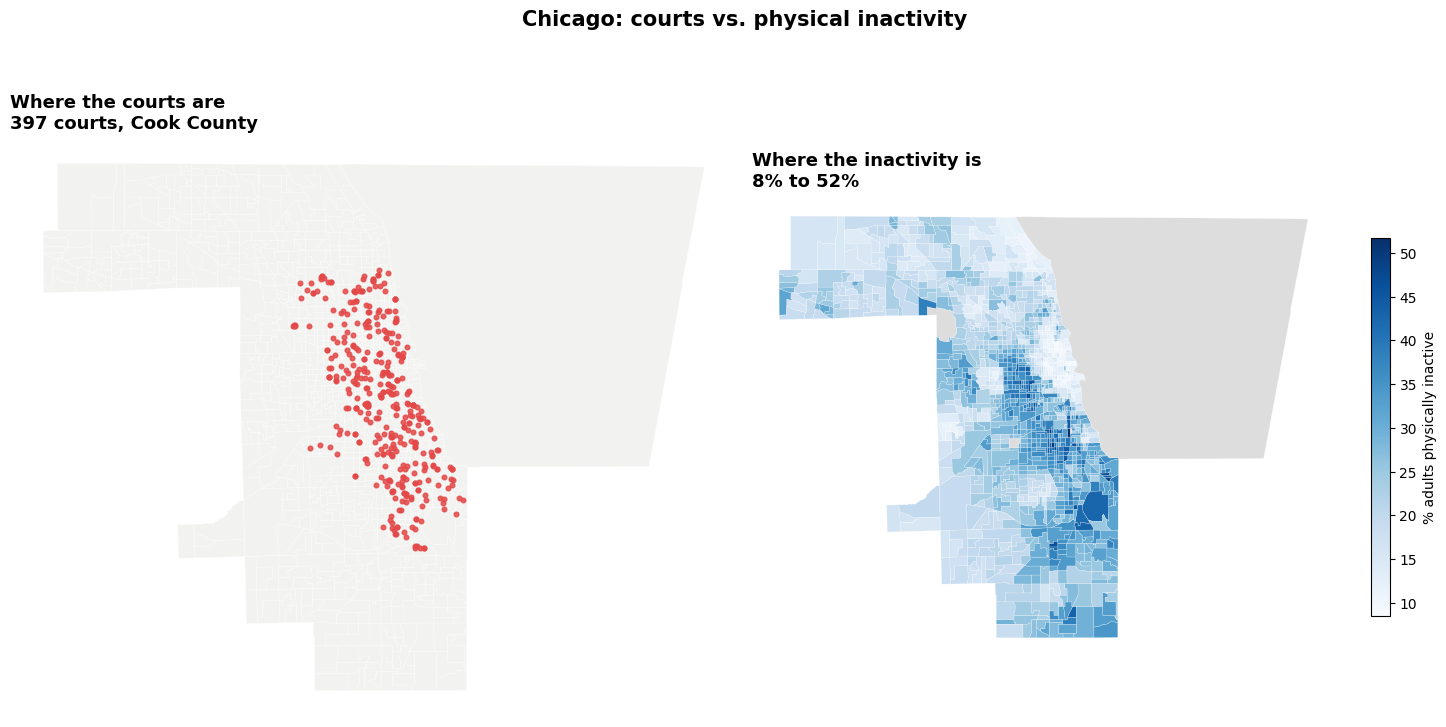

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# LEFT: dots, not a choropleth. With most tracts at zero and a long tail, a
# density ramp washes every real tract to near-white and implies a pattern
# that is not in the data.
analysis.plot(ax=axes[0], color="#f2f2f0", edgecolor="white", linewidth=0.2)
courts.plot(ax=axes[0], color="#e34948", markersize=11, alpha=0.85)
axes[0].set_title(f"Where the courts are\n{len(courts)} courts, {COUNTY_LABEL}",
                  fontsize=13, loc="left", fontweight="bold")

# RIGHT: single-hue sequential ramp — lightness carries magnitude, so it stays
# readable under colour-vision deficiency. Not viridis (multi-hue), never red-green.
analysis.plot(ax=axes[1], column="LPA", cmap="Blues", legend=True,
              edgecolor="white", linewidth=0.15, missing_kwds={"color": "#dddddd"},
              legend_kwds={"shrink": 0.55, "label": "% adults physically inactive"})
axes[1].set_title(f"Where the inactivity is\n{analysis.LPA.min():.0f}% to "
                  f"{analysis.LPA.max():.0f}%", fontsize=13, loc="left", fontweight="bold")

for ax in axes:
    ax.set_axis_off()
fig.suptitle(f"{CITY}: courts vs. physical inactivity", fontsize=15, y=0.97,
             fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [15]:
## Neighborhood names
import pandas as pd
from shapely import wkt

# This export is a CSV with WKT geometry in `the_geom`, not a spatial file —
# read_file() would treat it as a plain table with no geometry.
h = pd.read_csv(PATHS["hoods"])
h["geometry"] = h["the_geom"].apply(wkt.loads)
hoods = gpd.GeoDataFrame(h[["PRI_NEIGH", "geometry"]],
                         geometry="geometry", crs="EPSG:4326").to_crs(analysis.crs)

# Centroid, not polygon: a tract can straddle several neighborhoods, and
# 'within' on polygons would drop any tract not fully inside one.
tp = analysis[["GEOID", "geometry"]].copy()
tp["geometry"] = tp.geometry.centroid
labeled = (gpd.sjoin(tp, hoods, how="left", predicate="within")
           .drop(columns="index_right")
           .rename(columns={"PRI_NEIGH": "neighborhood"}))

named = analysis.merge(labeled[["GEOID", "neighborhood"]], on="GEOID", how="left")

# The layer covers Chicago proper; suburban Cook tracts stay unnamed.
print(f"{named.neighborhood.isna().sum()} of {len(named)} unnamed (suburban Cook)")

print(f"\n=== {CITY}: highest inactivity WITH courts present ===")
print(named[named.neighborhood.notna() & (named.court_count > 0)]
      .nlargest(14, "LPA")[["neighborhood", "LPA", "OBESITY", "court_count",
                            "median_household_income", "pct_black"]]
      .round(1).to_string(index=False))

# Neighborhood-level rollup — the honest unit for prose claims, since
# Englewood spans 30 tracts while Fuller Park spans 2.
print(f"\n=== {CITY}: neighborhood rollup, worst inactivity ===")
roll = (named[named.neighborhood.notna()]
        .groupby("neighborhood", observed=True)
        .agg(tracts=("GEOID", "size"), courts=("court_count", "sum"),
             LPA=("LPA", "median"), OBESITY=("OBESITY", "median"),
             income=("median_household_income", "median"),
             pct_black=("pct_black", "median"), pop=("total_population", "sum"))
        .round(1))
print(roll[roll.courts > 0].nlargest(12, "LPA").to_string())


551 of 1332 unnamed (suburban Cook)

=== Chicago: highest inactivity WITH courts present ===
  neighborhood  LPA  OBESITY  court_count  median_household_income  pct_black
      New City 49.9     45.6            1                  32056.0        0.0
 Garfield Park 47.1     51.4            2                  24375.0       98.7
 South Chicago 47.0     47.6            1                  33048.0       57.8
 Garfield Park 46.1     50.1            2                  22642.0       94.1
  West Pullman 45.6     45.4            2                  29747.0       40.6
     Englewood 45.2     50.5            2                  21888.0       95.1
   Fuller Park 44.6     49.8            3                  20669.0       76.7
 South Chicago 44.0     46.2            1                  40694.0       46.8
 Armour Square 43.9     49.2            1                  20588.0       84.3
     Riverdale 43.2     51.3            4                  16176.0       94.0
Little Village 43.0     40.1            3        

/var/folders/cm/46nnvpl978b_vb10b1dp7rp80000gn/T/ipykernel_2084/1309889115.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tp["geometry"] = tp.geometry.centroid
